In [2]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import ticker 
from scipy.interpolate import interp1d
import pandas as pd
LG10 = np.log(10)

In [4]:
def x_axis_customize(
    ax:plt.Axes,
    x_interval = 1,  # Example value for major tick interval
    x_minorLocater_num = 5,  # Example value for number of minor ticks between major ticks
    ):

    ax.tick_params(axis='both', which='both', direction='in')
    ax.xaxis.set_ticks_position('both')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(x_interval)) 
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(x_minorLocater_num))
    ax.xaxis.set_tick_params(which='major', length=5)
    ax.xaxis.set_tick_params(which='minor', length=3)
    
    return None

def y_axis_customize(
    ax:plt.Axes,
    y_interval = 1,  # Example value for major tick interval
    y_minorLocater_num = 5,  # Example value for number of minor ticks between major ticks
    ):

    ax.tick_params(axis='both', which='both', direction='in')
    ax.yaxis.set_ticks_position('both')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(y_interval)) 
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(y_minorLocater_num))
    ax.yaxis.set_tick_params(which='major', length=5)
    ax.yaxis.set_tick_params(which='minor', length=3)
    
    return None

In [6]:
# Read from table3.mrt file with robust parsing
import re

# Read and parse the MRT file
data_dr = {'mass': [], 'al26_tot': [], 'fe60_tot': []}
data_nr = {'mass': [], 'al26_tot': [], 'fe60_tot': []}

with open('./table3.mrt', 'r') as f:
    lines = f.readlines()

# Find the start of data (look for lines starting with DR or NR)
for line in lines:
    line = line.strip()
    if not line or line.startswith(('Title', 'Authors', 'Table', '=', '-', 'Byte', 'Label', 'Explanations', 'Notes')):
        continue
    
    # Match data lines: "DR/NR mass al26_tot ... fe60_tot ..."
    match = re.match(r'(DR|NR)\s+(\d+)\s+([\d.e\-+]+)\s+([\d.e\-+]+)\s+([\d.e\-+]+)\s+([\d.e\-+]+)\s+([\d.e\-+]+)\s+([\d.e\-+]+)\s+([\d.e\-+]+)', line)
    
    if match:
        rate_type = match.group(1)
        mass_val = int(match.group(2))
        al26_tot = float(match.group(3))
        fe60_tot = float(match.group(7))  # 7th group is M_tot_60Fe
        
        if rate_type == 'DR':
            data_dr['mass'].append(mass_val)
            data_dr['al26_tot'].append(al26_tot)
            data_dr['fe60_tot'].append(fe60_tot)
        else:  # NR
            data_nr['mass'].append(mass_val)
            data_nr['al26_tot'].append(al26_tot)
            data_nr['fe60_tot'].append(fe60_tot)

# Convert to numpy arrays
mass = np.array(data_dr['mass'])
yields_al26_dr = np.array(data_dr['al26_tot'])
yields_fe60_dr = np.array(data_dr['fe60_tot'])

yields_al26_nr = np.array(data_nr['al26_tot'])
yields_fe60_nr = np.array(data_nr['fe60_tot'])

In [7]:
f_al_dr = interp1d(mass, yields_al26_dr, kind='linear', )#fill_value='extrapolate')
f_al_nr = interp1d(mass, yields_al26_nr, kind='linear', )#fill_value='extrapolate')
f_fe_dr = interp1d(mass, yields_fe60_dr, kind='linear', )#fill_value='extrapolate')
f_fe_nr = interp1d(mass, yields_fe60_nr, kind='linear', )#fill_value='extrapolate')

In [8]:
mass_new = np.linspace(14, 80, 50)
yields_al26_dr_new = f_al_dr(mass_new)
yields_al26_nr_new = f_al_nr(mass_new)
yields_fe60_dr_new = f_fe_dr(mass_new)
yields_fe60_nr_new = f_fe_nr(mass_new)

In [9]:
def flux_ratio_dr(x: float):
    IMF = np.power(mass_new, -(1+x))
    yields_fe60 = sum(yields_fe60_dr_new * IMF)
    yields_al26 = sum(yields_al26_dr_new * IMF)
    return 0.43 * yields_fe60 / yields_al26

def flux_ratio_nr(x: float):
    IMF = np.power(mass_new, -(1+x))
    yields_fe60 = sum(yields_fe60_nr_new * IMF)
    yields_al26 = sum(yields_al26_nr_new * IMF)
    return 0.43 * yields_fe60 / yields_al26


print(flux_ratio_dr(1.35))
print(flux_ratio_nr(1.35))


0.3169434308475161
0.18320761827786103


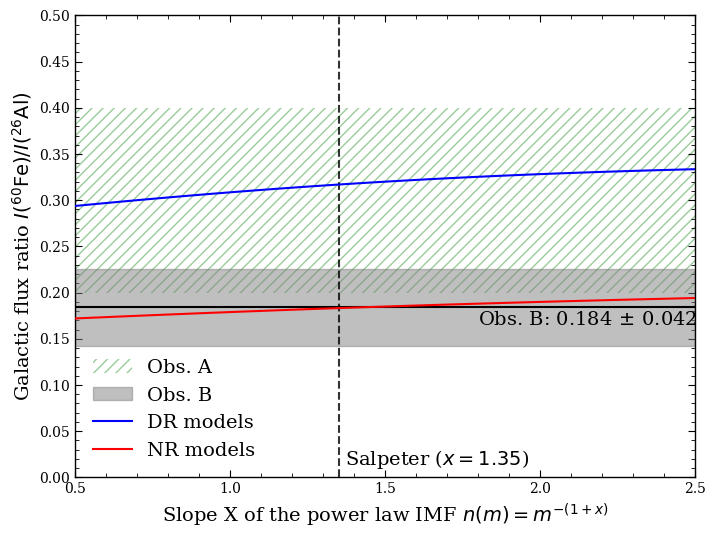

In [11]:
plt.rcParams['font.family'] = 'DejaVu Serif'

x = np.linspace(0.5, 2.5, 50)
ratio_dr = [flux_ratio_dr(i) for i in x]
ratio_nr = [flux_ratio_nr(i) for i in x]

# 观测约束范围 (根据 Wang+20 的数据)
# Observation B (Exponential Disk): 假设为主要阴影
obs_b_val = 0.184
obs_b_err = 0.042
obs_b_min, obs_b_max = obs_b_val - obs_b_err, obs_b_val + obs_b_err

# Observation A (Spatial Morphology): 假设为斜纹阴影
obs_a_min, obs_a_max = 0.2, 0.4

fig, ax = plt.subplots(figsize=(8,6))

plt.rcParams.update({
    #"font.family": "serif",      # ApJ 使用衬线体 (如 Times New Roman)
    "xtick.direction": "in",     # 刻度向内
    "ytick.direction": "in",
    "xtick.top": True,           # 开启顶部和右侧刻度
    "ytick.right": True,
    "axes.linewidth": 1.0,
    "legend.frameon": False      # 图例无边框
})



#plt.plot(x, ratio_lc, c='k', linestyle='-', label='LC06, 14-80M')
#plt.plot(x_lc_comp, ratio_lc_comp, c='k', linestyle='--',label='LC06, 11-120M')


# Observation A: 斜纹阴影 (Hatched region)
ax.axhspan(obs_a_min, obs_a_max, facecolor='none', edgecolor='green', 
            linewidth=0, hatch='///', alpha=0.4,
            label=r'Obs. A', zorder=1)

# Observation B: 实色阴影 ()
ax.axhspan(obs_b_min, obs_b_max, color='grey', alpha=0.5, 
            label=r'Obs. B', zorder=2)


ax.plot(x, ratio_dr, c='b', label='DR models', zorder=7)
ax.plot(x, ratio_nr, c='r', label='NR models', zorder=8)

# Salpeter Slope (x = 1.35)
ax.axvline(x=1.35, color='black', linestyle='--', alpha=0.8, zorder=3)
ax.text(1.37, 0.02, r'Salpeter ($x=1.35$)', rotation=0, verticalalignment='center', zorder=4, fontsize=14)

ax.axhline(y=0.184, color='k', linestyle='-', alpha=1.0, zorder=5)
ax.text(1.8, 0.17, r'Obs. B: 0.184$\,\pm\,$0.042', rotation=0, verticalalignment='center', zorder=6, fontsize=14)


# ax.errorbar(
#     1.35, 0.184, 
#     yerr=0.042, 
#     fmt='o', 
#     color='k', 
#     label='Observation B (Wang+20)', 
#     alpha=0.5,
#     capsize=3,
# )
# ax.axhspan(ymin=0.2, ymax=0.4, alpha=0.3, color='grey', label='Observation A (Wang+20)')


ax.set_xlim(0.5, 2.5)
ax.set_ylim(0.0, 0.5)
#plt.title(r"$^{60}$Fe/$^{26}$Al flux ratio, mass rage 14-80 $M_\odot$")
ax.set_xlabel(r"Slope X of the power law IMF $n(m)=m^{-(1+x)}$", fontsize=14)
ax.set_ylabel(r'Galactic flux ratio $I(^{60}\mathrm{Fe})/I(^{26}\mathrm{Al})$', fontsize=14)


x_axis_customize(ax, 0.5, 5)
y_axis_customize(ax, 0.05, 5)
ax.legend(loc='lower left', fontsize=14)

plt.show()